# SIT320 - Network-based Algorithms

Karger's algorithm for global minimum cut, a weighted extension of it, and Ford-Fulkerson for maximum flow and minimum s-t cut. No template was provided for this module, so the code is my own. Ford-Fulkerson follows CLRS chapter 26; the programiz page linked in the task sheet was used as a reference for the adjacency-matrix layout.

***

### <font color='red'> Section 0: Imports </font>

In [1]:
import random
import copy
from collections import deque, Counter
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

***

### <font color='red'> Section 1: Karger's algorithm (global minimum cut, unweighted) </font>

The algorithm: pick a uniformly random edge, contract its two endpoints into one super-node, repeat until two super-nodes are left. The edges still running between the two super-nodes are the cut.

I keep the graph as an edge list and track super-nodes with a union-find structure. Contracting an edge is one `union`. Self-loops (edges whose endpoints are already in the same super-node) are skipped when picking. At the end the cut size is the number of edges whose endpoints are in different super-nodes.

In [2]:
class UnionFind:
    """Tracks which original vertex belongs to which super-node."""
    def __init__(self, vertices):
        self.parent = {v: v for v in vertices}
        self.count = len(vertices)          # number of super-nodes still alive

    def find(self, v):
        while self.parent[v] != v:
            self.parent[v] = self.parent[self.parent[v]]   # path halving
            v = self.parent[v]
        return v

    def union(self, u, v):
        ru, rv = self.find(u), self.find(v)
        if ru != rv:
            self.parent[ru] = rv
            self.count -= 1


def karger(vertices, edges, rng=random):
    """One run of Karger's contraction algorithm.

    Returns (cut_size, (side_A, side_B)). Each contraction picks a uniformly random
    edge among those that still join two different super-nodes.
    """
    uf = UnionFind(vertices)
    live = list(edges)                      # edges not yet collapsed into a self-loop
    while uf.count > 2:
        u, v = rng.choice(live)
        if uf.find(u) == uf.find(v):        # became a self-loop by an earlier contraction
            live.remove((u, v))
            continue
        uf.union(u, v)
    cut = [(u, v) for u, v in edges if uf.find(u) != uf.find(v)]
    root = uf.find(vertices[0])
    A = sorted(v for v in vertices if uf.find(v) == root)
    B = sorted(v for v in vertices if uf.find(v) != root)
    return len(cut), (A, B), cut

Test graph: two 4-cliques joined by two edges. The global minimum cut is those two bridging edges, size 2, and it is the only cut of size 2. Every vertex has degree 3 or 4, so every single-vertex cut costs at least 3.

In [3]:
def two_cliques():
    left, right = ['A', 'B', 'C', 'D'], ['E', 'F', 'G', 'H']
    edges = []
    for group in (left, right):
        for i in range(4):
            for j in range(i + 1, 4):
                edges.append((group[i], group[j]))
    edges += [('B', 'E'), ('D', 'E')]        # the bridge: min cut = 2
    return left + right, edges

V, E = two_cliques()
print(len(V), "vertices,", len(E), "edges")
random.seed(320)
size, (A, B), cut = karger(V, E)
print("one run: cut size", size, "  sides", A, B, "  cut edges", cut)

8 vertices, 14 edges
one run: cut size 4   sides ['A', 'C', 'D'] ['B', 'E', 'F', 'G', 'H']   cut edges [('A', 'B'), ('B', 'C'), ('B', 'D'), ('D', 'E')]


[(2, 2172), (3, 5317), (4, 2161), (5, 350)]

fraction of runs that found the min cut: 0.217
theoretical lower bound 2/(n(n-1)) = 2/56 = 0.036


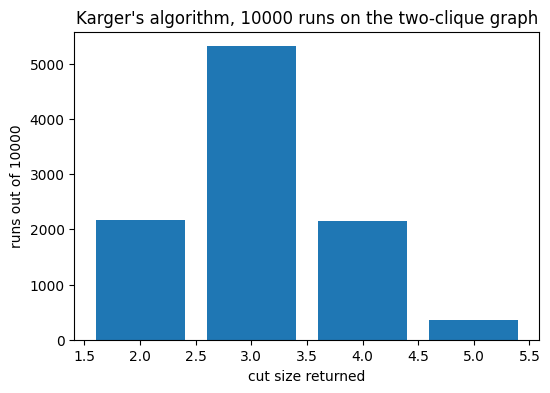

In [4]:
# Repeat 10000 times and look at the distribution of cut sizes, as in the module notes.
random.seed(320)
runs = [karger(V, E)[0] for _ in range(10000)]
dist = Counter(runs)
print(sorted(dist.items()))
n = len(V)
print(f"\nfraction of runs that found the min cut: {dist[2] / len(runs):.3f}")
print(f"theoretical lower bound 2/(n(n-1)) = 2/{n*(n-1)} = {2 / (n*(n-1)):.3f}")

plt.figure(figsize=(6, 4))
sizes = sorted(dist)
plt.bar(sizes, [dist[s] for s in sizes])
plt.xlabel("cut size returned"); plt.ylabel("runs out of 10000")
plt.title("Karger's algorithm, 10000 runs on the two-clique graph");

Repetition. One run succeeds with probability $p \ge 2/(n(n-1))$. Running $T$ times and keeping the smallest cut fails only if every run fails, probability at most $(1-p)^T \le e^{-pT}$. Setting that to $\delta$ gives $T = \ln(1/\delta)\,n(n-1)/2$.

In [5]:
import math
def runs_needed(n, delta):
    return math.ceil(math.log(1 / delta) * n * (n - 1) / 2)

for delta in (0.1, 0.01, 0.001):
    print(f"n = {n}, delta = {delta:<6} ->  T = {runs_needed(n, delta)} runs")

# Empirical check: batches of T runs, keep the best, how often is the best equal to 2?
random.seed(1)
T = runs_needed(n, 0.01)
batches = 300
hits = sum(min(karger(V, E)[0] for _ in range(T)) == 2 for _ in range(batches))
print(f"\nkeep-the-best over T = {T} runs, repeated {batches} times: correct {hits}/{batches} = {hits / batches:.3f}  (target >= 0.99)")

n = 8, delta = 0.1    ->  T = 65 runs
n = 8, delta = 0.01   ->  T = 129 runs
n = 8, delta = 0.001  ->  T = 194 runs



keep-the-best over T = 129 runs, repeated 300 times: correct 300/300 = 1.000  (target >= 0.99)


***

### <font color='red'> Section 2: Weighted minimum cut, extending Karger (Task 2) </font>

Change from Section 1: an edge is picked with probability proportional to its weight, not uniformly. A weighted edge of weight $w$ behaves exactly like $w$ parallel unit edges in the unweighted algorithm, where each of those $w$ copies has the same chance of being chosen. So weight-proportional selection is the unweighted algorithm run on the multigraph, and the analysis carries over: the probability of returning a minimum-weight cut is still at least $2/(n(n-1))$.

Contraction is the same union operation. When two super-nodes merge, parallel edges between the survivors add their weights, which the edge list handles for free because the cut weight is the sum over crossing edges.

The cut cost is the sum of weights of the crossing edges, not their count.

In [6]:
def karger_weighted(vertices, wedges, rng=random):
    """One run of weighted Karger. wedges is a list of (u, v, w).

    Edge selection is weight-proportional: random.choices with weights = w.
    Returns (cut_weight, (side_A, side_B), cut_edges).
    """
    uf = UnionFind(vertices)
    live = list(wedges)
    while uf.count > 2:
        weights = [w for _, _, w in live]
        u, v, w = rng.choices(live, weights=weights, k=1)[0]
        if uf.find(u) == uf.find(v):
            live.remove((u, v, w))
            continue
        uf.union(u, v)
    cut = [(u, v, w) for u, v, w in wedges if uf.find(u) != uf.find(v)]
    root = uf.find(vertices[0])
    A = sorted(v for v in vertices if uf.find(v) == root)
    B = sorted(v for v in vertices if uf.find(v) != root)
    return sum(w for _, _, w in cut), (A, B), cut


def min_cut_brute_force(vertices, wedges):
    """Check every non-empty proper subset containing vertices[0]. Only for small graphs."""
    best = (float('inf'), None)
    rest = vertices[1:]
    for mask in range(0, 2 ** len(rest) - 1):       # exclude the mask that puts everything on one side
        S = {vertices[0]} | {rest[i] for i in range(len(rest)) if mask >> i & 1}
        cost = sum(w for u, v, w in wedges if (u in S) != (v in S))
        if cost < best[0]:
            best = (cost, sorted(S))
    return best

Test graph: the two cliques again, but now the two bridge edges are heavy (weight 10 each, total 20) and one vertex, H, is attached to its clique by three light edges of weight 1. The unweighted min cut is still the bridge (2 edges), but the weighted min cut is $\{H\}$ against everything else at cost 3. A correct weighted algorithm has to find the cost-3 cut, and the unweighted algorithm, which counts edges, never will.

In [7]:
def two_cliques_weighted():
    V, E = two_cliques()
    WE = []
    for u, v in E:
        if (u, v) in [('B', 'E'), ('D', 'E')]:
            WE.append((u, v, 10))               # heavy bridge
        elif 'H' in (u, v):
            WE.append((u, v, 1))                # H hangs on by three weight-1 edges
        else:
            WE.append((u, v, 5))
    return V, WE

V, WE = two_cliques_weighted()
print("brute force minimum weight cut:", min_cut_brute_force(V, WE))

random.seed(320)
cost, (A, B), cut = karger_weighted(V, WE)
print("one weighted run:", cost, A, B, cut)

brute force minimum weight cut: (3, ['A', 'B', 'C', 'D', 'E', 'F', 'G'])
one weighted run: 3 ['A', 'B', 'C', 'D', 'E', 'F', 'G'] ['H'] [('E', 'H', 1), ('F', 'H', 1), ('G', 'H', 1)]


weight-proportional selection: [(3, 5714), (11, 1822), (12, 831), (15, 852), (20, 370), (25, 325), (30, 86)]
uniform selection, weighted score: [(3, 832), (11, 2645), (12, 688), (15, 1840), (20, 2458), (25, 1187), (30, 350)]

found the cost-3 cut: weighted 0.571   uniform 0.083   bound 2/(n(n-1)) = 0.036


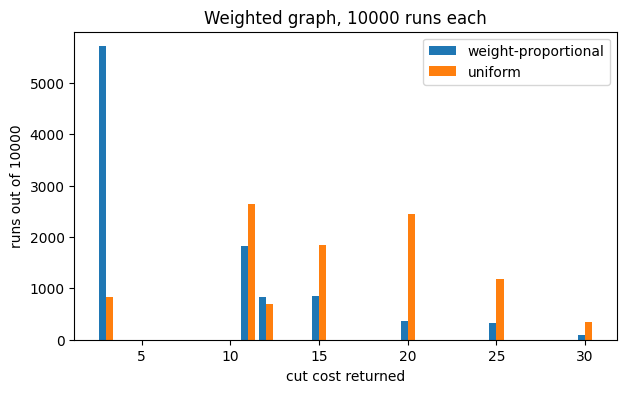

In [8]:
# Distribution over 10000 runs for the weighted algorithm, and for the unweighted picker scoring the same weights
random.seed(320)
weighted_runs = [karger_weighted(V, WE)[0] for _ in range(10000)]

# unweighted Karger on the same edges, but score the cut it returns by weight, to show why uniform selection is wrong here
random.seed(320)
E_only = [(u, v) for u, v, _ in WE]
wt = {(u, v): w for u, v, w in WE}
uniform_runs = [sum(wt[e] for e in karger(V, E_only)[2]) for _ in range(10000)]

wd, ud = Counter(weighted_runs), Counter(uniform_runs)
print("weight-proportional selection:", sorted(wd.items()))
print("uniform selection, weighted score:", sorted(ud.items()))
print(f"\nfound the cost-3 cut: weighted {wd[3] / 10000:.3f}   uniform {ud[3] / 10000:.3f}   bound 2/(n(n-1)) = {2 / (n * (n - 1)):.3f}")

plt.figure(figsize=(7, 4))
xs = sorted(set(wd) | set(ud))
w = 0.4
plt.bar([x - w/2 for x in xs], [wd[x] for x in xs], width=w, label='weight-proportional')
plt.bar([x + w/2 for x in xs], [ud[x] for x in xs], width=w, label='uniform')
plt.xlabel("cut cost returned"); plt.ylabel("runs out of 10000"); plt.legend()
plt.title("Weighted graph, 10000 runs each");

In [9]:
# Repetition works the same way: T = ln(1/delta) n(n-1)/2 runs, keep the cheapest cut
random.seed(2)
T = runs_needed(n, 0.01)
batches = 300
hits = sum(min(karger_weighted(V, WE)[0] for _ in range(T)) == 3 for _ in range(batches))
print(f"keep-the-best over T = {T} runs, repeated {batches} times: correct {hits}/{batches} = {hits / batches:.3f}  (target >= 0.99)")

keep-the-best over T = 129 runs, repeated 300 times: correct 300/300 = 1.000  (target >= 0.99)


***

### <font color='red'> Section 3: Ford-Fulkerson on the seminar network (Task 3) </font>

The graph from the task sheet. The unlabelled nodes are named a, b, c (left column, top to bottom) and d, e, f (right column, top to bottom). All edges are directed as drawn; note f -> b points back toward the left column.

Capacities are stored in a dictionary `cap[u][v]`. The residual capacity of (u, v) is `cap[u][v] - flow[u][v]` for a forward edge, and `flow[v][u]` for the reverse direction (flow that could be cancelled). I keep both in one residual dictionary `res` so that path search does not need to know which kind of edge it is walking.

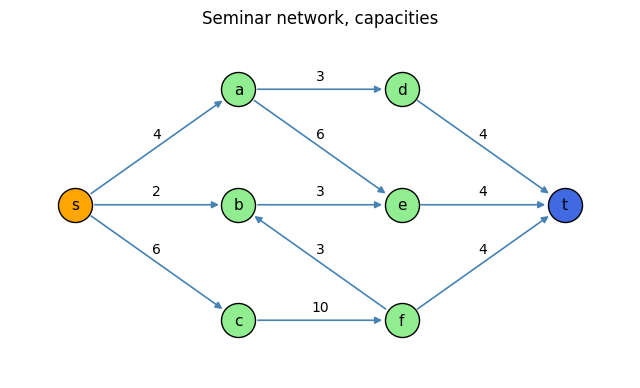

In [10]:
def seminar_graph():
    edges = [('s', 'a', 4), ('s', 'b', 2), ('s', 'c', 6),
             ('a', 'd', 3), ('a', 'e', 6),
             ('b', 'e', 3),
             ('f', 'b', 3),
             ('c', 'f', 10),
             ('d', 't', 4), ('e', 't', 4), ('f', 't', 4)]
    nodes = ['s', 'a', 'b', 'c', 'd', 'e', 'f', 't']
    cap = {u: {v: 0 for v in nodes} for u in nodes}
    for u, v, c in edges:
        cap[u][v] = c
    return nodes, cap, edges

nodes, cap, edge_list = seminar_graph()
pos = {'s': (0, 1), 'a': (1, 2), 'b': (1, 1), 'c': (1, 0), 'd': (2, 2), 'e': (2, 1), 'f': (2, 0), 't': (3, 1)}

def draw_network(cap, flow=None, cut=None, title=""):
    plt.figure(figsize=(8, 4.5))
    ax = plt.gca()
    for u in cap:
        for v in cap[u]:
            if cap[u][v] == 0:
                continue
            (x1, y1), (x2, y2) = pos[u], pos[v]
            in_cut = cut is not None and (u, v) in cut
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                        arrowprops=dict(arrowstyle="-|>", lw=2.5 if in_cut else 1.2,
                                        color="red" if in_cut else "steelblue", shrinkA=14, shrinkB=14))
            label = f"{flow[u][v]}/{cap[u][v]}" if flow is not None else str(cap[u][v])
            ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.08, label, ha="center", fontsize=10,
                    color="red" if in_cut else "black")
    for v, (x, y) in pos.items():
        ax.scatter(x, y, s=600, color="orange" if v == 's' else "royalblue" if v == 't' else "lightgreen", zorder=5, edgecolor="k")
        ax.text(x, y, v, ha="center", va="center", fontsize=11, zorder=6)
    ax.set_xlim(-0.4, 3.4); ax.set_ylim(-0.5, 2.5); ax.axis("off"); ax.set_title(title)

draw_network(cap, title="Seminar network, capacities")

Ford-Fulkerson. Start with zero flow. Repeatedly find any s-t path in the residual graph, push the bottleneck (smallest residual capacity on the path) along it, update the residual graph, stop when no path exists. The path search is a parameter: BFS gives Edmonds-Karp, DFS gives the plain version. Each augmentation adds the bottleneck to the flow value, and the search that finally fails gives the min cut for free: the set of nodes it could still reach from s is one side of the cut.

In [11]:
def bfs_path(res, s, t):
    """Shortest s-t path (fewest edges) in the residual graph, or None."""
    parent = {s: None}
    q = deque([s])
    while q:
        u = q.popleft()
        for v, r in res[u].items():
            if r > 0 and v not in parent:
                parent[v] = u
                if v == t:
                    path = [t]
                    while parent[path[-1]] is not None:
                        path.append(parent[path[-1]])
                    return path[::-1]
                q.append(v)
    return None


def dfs_path(res, s, t):
    """Any s-t path in the residual graph, found depth-first, or None."""
    parent = {s: None}
    stack = [s]
    while stack:
        u = stack.pop()
        if u == t:
            path = [t]
            while parent[path[-1]] is not None:
                path.append(parent[path[-1]])
            return path[::-1]
        for v, r in res[u].items():
            if r > 0 and v not in parent:
                parent[v] = u
                stack.append(v)
    return None


def reachable(res, s):
    seen = {s}
    stack = [s]
    while stack:
        u = stack.pop()
        for v, r in res[u].items():
            if r > 0 and v not in seen:
                seen.add(v); stack.append(v)
    return seen


def ford_fulkerson(cap, s, t, find_path=bfs_path, verbose=True):
    """Returns (max_flow_value, flow, residual, min_cut_edges, S_side, iterations)."""
    nodes = list(cap)
    flow = {u: {v: 0 for v in nodes} for u in nodes}
    res = copy.deepcopy(cap)                 # residual: cap - flow forward, flow backward
    total, iterations = 0, 0
    while True:
        path = find_path(res, s, t)
        if path is None:
            break
        iterations += 1
        bottleneck = min(res[u][v] for u, v in zip(path, path[1:]))
        for u, v in zip(path, path[1:]):
            if cap[u][v] > 0 and flow[u][v] + bottleneck <= cap[u][v]:
                flow[u][v] += bottleneck     # push forward on a real edge
            else:
                flow[v][u] -= bottleneck     # cancel flow on the reverse of a real edge
            res[u][v] -= bottleneck
            res[v][u] += bottleneck
        total += bottleneck
        if verbose:
            print(f"iteration {iterations}: path {' -> '.join(path)}, bottleneck {bottleneck}, flow so far {total}")
    S = reachable(res, s)
    cut = [(u, v) for u in cap for v in cap[u] if cap[u][v] > 0 and u in S and v not in S]
    return total, flow, res, cut, S, iterations

In [12]:
total, flow, res, cut, S, its = ford_fulkerson(cap, 's', 't', bfs_path)

print(f"\nTotal flow value: {total}")
print("\nFlow on each edge (flow/capacity):")
for u, v, c in edge_list:
    print(f"  {u} -> {v}: {flow[u][v]}/{c}")
print("\nResidual graph (edges with residual capacity > 0):")
for u in nodes:
    for v in nodes:
        if res[u][v] > 0:
            kind = "forward, unused capacity" if cap[u][v] > 0 and flow[u][v] < cap[u][v] else "backward, flow that could be cancelled"
            print(f"  {u} -> {v}: {res[u][v]}   ({kind})")
print(f"\nNodes reachable from s in the residual graph (S side): {sorted(S)}")
print(f"T side: {sorted(set(nodes) - S)}")
print("\nMinimum cut edges (S -> T):")
for u, v in cut:
    print(f"  {u} -> {v}  capacity {cap[u][v]}")
print(f"Cut capacity: {sum(cap[u][v] for u, v in cut)}   (equals max flow: {sum(cap[u][v] for u, v in cut) == total})")

iteration 1: path s -> a -> d -> t, bottleneck 3, flow so far 3
iteration 2: path s -> a -> e -> t, bottleneck 1, flow so far 4
iteration 3: path s -> b -> e -> t, bottleneck 2, flow so far 6
iteration 4: path s -> c -> f -> t, bottleneck 4, flow so far 10
iteration 5: path s -> c -> f -> b -> e -> t, bottleneck 1, flow so far 11

Total flow value: 11

Flow on each edge (flow/capacity):
  s -> a: 4/4
  s -> b: 2/2
  s -> c: 5/6
  a -> d: 3/3
  a -> e: 1/6
  b -> e: 3/3
  f -> b: 1/3
  c -> f: 5/10
  d -> t: 3/4
  e -> t: 4/4
  f -> t: 4/4

Residual graph (edges with residual capacity > 0):
  s -> c: 1   (forward, unused capacity)
  a -> s: 4   (backward, flow that could be cancelled)
  a -> e: 5   (forward, unused capacity)
  b -> s: 2   (backward, flow that could be cancelled)
  b -> f: 1   (backward, flow that could be cancelled)
  c -> s: 5   (backward, flow that could be cancelled)
  c -> f: 5   (forward, unused capacity)
  d -> a: 3   (backward, flow that could be cancelled)
  d -

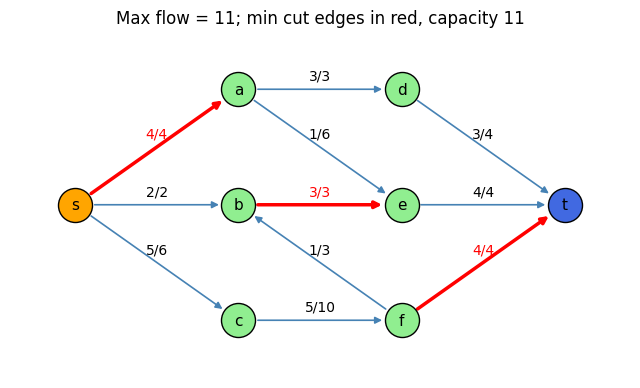

In [13]:
draw_network(cap, flow=flow, cut=set(cut), title=f"Max flow = {total}; min cut edges in red, capacity {sum(cap[u][v] for u, v in cut)}")

In [14]:
# Check the flow is valid: capacity respected on every edge, conservation at every internal node
ok_cap = all(0 <= flow[u][v] <= cap[u][v] for u in nodes for v in nodes)
balance = {v: sum(flow[u][v] for u in nodes) - sum(flow[v][w] for w in nodes) for v in nodes}
print("capacity constraints hold:", ok_cap)
print("net inflow at each node:", balance)
print("conservation holds at internal nodes:", all(balance[v] == 0 for v in nodes if v not in ('s', 't')))
print("flow out of s:", -balance['s'], " flow into t:", balance['t'])

capacity constraints hold: True
net inflow at each node: {'s': -11, 'a': 0, 'b': 0, 'c': 0, 'd': 0, 'e': 0, 'f': 0, 't': 11}
conservation holds at internal nodes: True
flow out of s: 11  flow into t: 11


BFS versus DFS. Both give the same max flow value (any augmenting-path order does), but the number of augmentations can differ. BFS always takes a shortest path, and Edmonds-Karp proves that gives at most $O(VE)$ augmentations regardless of capacities. DFS takes whatever path it finds first, and with unlucky capacities it can take a number of augmentations proportional to the max flow value itself.

In [15]:
print("BFS (Edmonds-Karp):")
t_bfs = ford_fulkerson(cap, 's', 't', bfs_path)
print("\nDFS:")
t_dfs = ford_fulkerson(cap, 's', 't', dfs_path)
print(f"\nseminar graph: max flow BFS {t_bfs[0]} in {t_bfs[5]} iterations, DFS {t_dfs[0]} in {t_dfs[5]} iterations")
print("same cut:", sorted(t_bfs[3]) == sorted(t_dfs[3]))

BFS (Edmonds-Karp):
iteration 1: path s -> a -> d -> t, bottleneck 3, flow so far 3
iteration 2: path s -> a -> e -> t, bottleneck 1, flow so far 4
iteration 3: path s -> b -> e -> t, bottleneck 2, flow so far 6
iteration 4: path s -> c -> f -> t, bottleneck 4, flow so far 10
iteration 5: path s -> c -> f -> b -> e -> t, bottleneck 1, flow so far 11

DFS:
iteration 1: path s -> c -> f -> t, bottleneck 4, flow so far 4
iteration 2: path s -> b -> e -> t, bottleneck 2, flow so far 6
iteration 3: path s -> c -> f -> b -> e -> t, bottleneck 1, flow so far 7
iteration 4: path s -> a -> e -> t, bottleneck 1, flow so far 8
iteration 5: path s -> a -> d -> t, bottleneck 3, flow so far 11

seminar graph: max flow BFS 11 in 5 iterations, DFS 11 in 5 iterations
same cut: True


In [16]:
# The textbook worst case: s->a, s->b, a->t, b->t all capacity K, and one edge a->b of capacity 1.
# Max flow is 2K. If the path search keeps choosing a path through the middle edge, each augmentation
# pushes only 1 unit (through a->b, then cancelling it back through b->a), so it takes 2K augmentations.
# My stack-based DFS happens to find the direct paths on this graph, so to show the effect I use a
# chooser that takes the middle path whenever it has residual capacity, which is a legal DFS order.
def bad_case(K):
    nodes = ['s', 'a', 'b', 't']
    cap = {u: {v: 0 for v in nodes} for u in nodes}
    cap['s']['a'] = cap['s']['b'] = cap['a']['t'] = cap['b']['t'] = K
    cap['a']['b'] = 1
    return cap

def middle_first_path(res, s, t):
    for path in (['s', 'a', 'b', 't'], ['s', 'b', 'a', 't']):
        if all(res[u][v] > 0 for u, v in zip(path, path[1:])):
            return path
    return dfs_path(res, s, t)

for K in (10, 100, 1000):
    cb = bad_case(K)
    fb = ford_fulkerson(cb, 's', 't', bfs_path, verbose=False)
    fm = ford_fulkerson(cb, 's', 't', middle_first_path, verbose=False)
    print(f"K = {K:>5}: max flow {fb[0]}, BFS augmentations {fb[5]}, middle-first DFS order {fm[5]}")

K =    10: max flow 20, BFS augmentations 2, middle-first DFS order 20
K =   100: max flow 200, BFS augmentations 2, middle-first DFS order 200
K =  1000: max flow 2000, BFS augmentations 2, middle-first DFS order 2000


In [17]:
# Typical case: random layered networks, BFS against a DFS that visits neighbours in random order.
# Same max flow every time; the count of augmentations is what differs.
def random_network(layers, width, rng):
    names = ['s'] + [f"n{l}_{i}" for l in range(layers) for i in range(width)] + ['t']
    cap = {u: {v: 0 for v in names} for u in names}
    cols = [['s']] + [[f"n{l}_{i}" for i in range(width)] for l in range(layers)] + [['t']]
    for A, B in zip(cols, cols[1:]):
        for u in A:
            for v in B:
                if rng.random() < 0.7:
                    cap[u][v] = rng.randint(1, 20)
    return cap

def dfs_random_order(rng):
    def find(res, s, t):
        parent = {s: None}; stack = [s]
        while stack:
            u = stack.pop()
            if u == t:
                path = [t]
                while parent[path[-1]] is not None:
                    path.append(parent[path[-1]])
                return path[::-1]
            nbrs = [v for v, r in res[u].items() if r > 0 and v not in parent]
            rng.shuffle(nbrs)
            for v in nbrs:
                parent[v] = u; stack.append(v)
        return None
    return find

rng = random.Random(7)
bfs_its, dfs_its, agree = [], [], 0
for trial in range(50):
    g = random_network(layers=4, width=5, rng=rng)
    rb = ford_fulkerson(g, 's', 't', bfs_path, verbose=False)
    rd = ford_fulkerson(g, 's', 't', dfs_random_order(rng), verbose=False)
    bfs_its.append(rb[5]); dfs_its.append(rd[5]); agree += rb[0] == rd[0]
print(f"50 random networks (22 nodes): same max flow in {agree}/50")
print(f"augmentations  BFS mean {np.mean(bfs_its):.1f} (max {max(bfs_its)})   DFS mean {np.mean(dfs_its):.1f} (max {max(dfs_its)})")

50 random networks (22 nodes): same max flow in 50/50
augmentations  BFS mean 8.7 (max 17)   DFS mean 8.9 (max 18)


***